# Embeddings with AION-1, via `lsdb` streaming of the Legacy Survey HATS catalog

`astropt_similarity_search.ipynb` and `aion_embeddings.ipynb` both use a
public per-object cutout API. This notebook instead uses
[`lsdb`](https://github.com/astronomy-commons/lsdb) — the SOTA framework
for large partitioned astronomical catalogs (HATS format) — against
[`hugging-science/mmu_legacysurvey_dr10_south_21`](https://huggingface.co/datasets/hugging-science/mmu_legacysurvey_dr10_south_21):
123M objects, 61 TiB, the same raw-flux Legacy Survey catalog family AION-1
was itself pretrained on.

`lsdb`'s value here is spatial partitioning: a `cone_search` around a query
coordinate resolves to the handful of HEALPix (HATS) partition files that
actually cover it — a few tens of MB each — instead of scanning the full
catalog. See `utils/lsdb_legacysurvey.py` for two workarounds this
environment needed (verified by hand, not theoretical):

1. lsdb's default threaded dask scheduler corrupts concurrent reads against
   this dataset's remote filesystem backend (`OSError: Couldn't deserialize
   thrift: ... Invalid data`) — every lsdb call runs under
   `dask.config.set(scheduler="synchronous")`.
2. Reading the wide `image`/`rgb` columns remotely hits the same corruption
   even single-threaded, so lsdb here only reads lightweight `ra`/`dec`/
   `object_id` metadata; the resolved partition files are downloaded with
   `huggingface_hub.hf_hub_download` (plain HTTP, no corruption) and parsed
   locally with `pyarrow` — still only the partitions the cone search
   identified.

From there this notebook mirrors `aion_embeddings.ipynb`: embed real flux
cutouts with the released `aion-base` checkpoint and rank by cosine
similarity.

## Install example-only dependencies

Not part of AstroLens' core install — only needed for this example.

In [ ]:
!pip install -q lsdb polymathic-aion huggingface_hub scikit-learn matplotlib pillow

## Imports

In [2]:
import numpy as np
import torch
from sklearn.metrics.pairwise import cosine_similarity

from utils.lsdb_legacysurvey import open_catalog, cone_search_pixels, download_partitions, load_table
from utils.aion import compute_image_embeddings
from astrolens.pretrained.aion import load_pretrained_aion

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Cone search: resolve, then download, only the needed partitions

Opens the HATS catalog's metadata (no row data yet), searches a 120
arcsecond cone around one sky position, and downloads only the partition
file(s) that cone touches — two ~75 MB files covering 197 objects here, out
of the catalog's full 61 TiB.

In [3]:
RA, DEC, RADIUS_ARCSEC = 22.7943, -12.2904, 120
N_EXAMPLES = 60

catalog = open_catalog()
pixels = cone_search_pixels(catalog, RA, DEC, RADIUS_ARCSEC)
paths = download_partitions(pixels)
table = load_table(paths)

table = table.sample(min(N_EXAMPLES, len(table)), random_state=0).reset_index(drop=True)
flux = np.stack(table["flux"].to_list())
flux.shape

(60, 4, 160, 160)

## Load AION-1 and compute embeddings

`load_pretrained_aion` (`astrolens/pretrained/aion.py`) downloads the
released `aion-base` checkpoint and its codec manager. Embeddings are
image-only, mean-pooled over encoder tokens — same as `aion_embeddings.ipynb`
and `astropt_similarity_search.ipynb`'s `compute_embeddings`.

In [4]:
model, codec_manager = load_pretrained_aion("aion-base", device=device)
embeddings = compute_image_embeddings(model, codec_manager, flux, device)

embeddings.shape

embedding:   0%|          | 0/4 [00:00<?, ?batch/s]

(60, 768)

## Similarity search

Ranks every cutout by cosine similarity to a query object's embedding and
shows its nearest neighbors, using the catalog's own `rgb` thumbnails
(same objects as the flux cutouts fed to the model, unlike
`aion_embeddings.ipynb`'s mismatched `gz10` thumbnails).

Text(0.5, 0.98, 'Nearest neighbors of query 0')

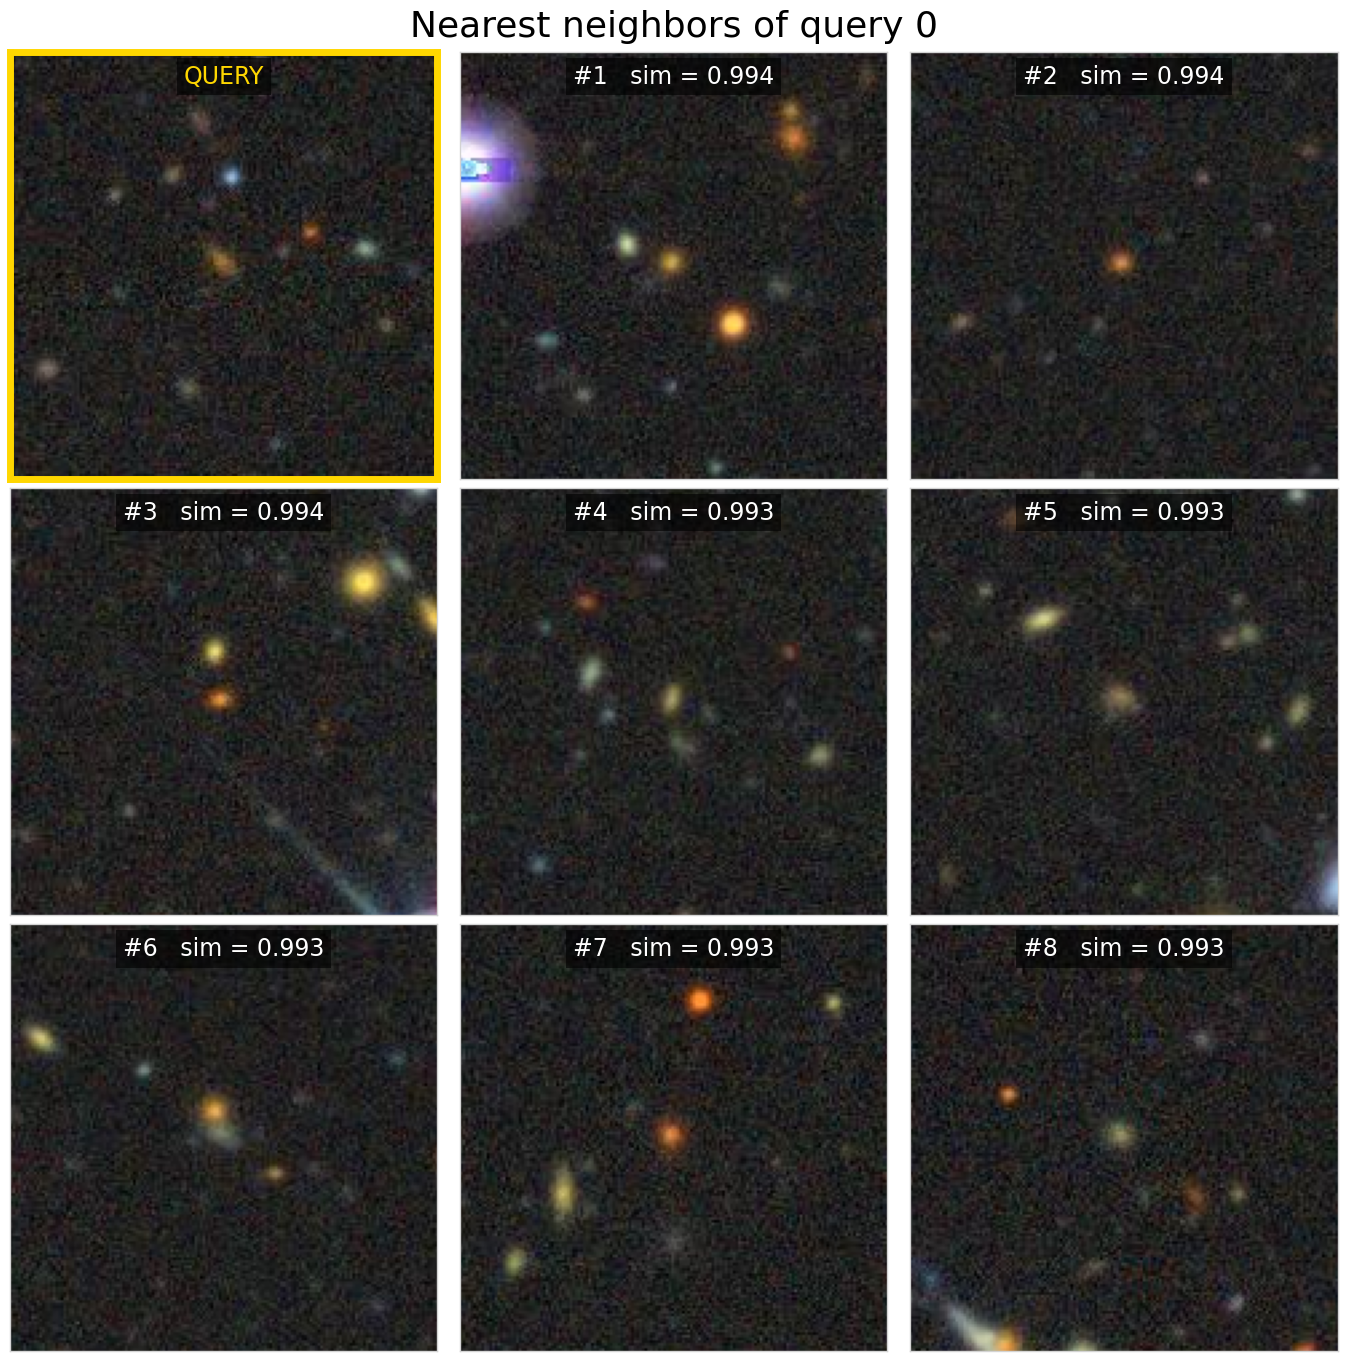

In [5]:
import io
import matplotlib.pyplot as plt
from PIL import Image

TOP_N = 8
N_COLS = 3
QUERY_IDX = 0  # pick any position

sims = cosine_similarity(embeddings[QUERY_IDX : QUERY_IDX + 1], embeddings)[0]
nearest = np.argsort(sims)[::-1][: TOP_N + 1]  # includes the query itself

n_rows = int(np.ceil(len(nearest) / N_COLS))
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(4.5 * N_COLS, 4.5 * n_rows), layout="constrained")
for rank, (ax, idx) in enumerate(zip(axes.flat, nearest)):
    is_query = idx == QUERY_IDX
    ax.imshow(Image.open(io.BytesIO(table["rgb"].iloc[idx])))
    ax.text(
        0.5, 0.97,
        "QUERY" if is_query else f"#{rank}   sim = {sims[idx]:.3f}",
        transform=ax.transAxes, ha="center", va="top", fontsize=17,
        color="gold" if is_query else "white",
        bbox=dict(facecolor="black", alpha=0.6, edgecolor="none", pad=5),
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set(color="gold" if is_query else "lightgray", linewidth=5 if is_query else 1)
for ax in axes.flat[len(nearest):]:
    ax.axis("off")
fig.suptitle(f"Nearest neighbors of query {QUERY_IDX}", fontsize=26)